# `03` — Mixed Activation Functions on Optical Digit Recognition

This experiment extends the regression study from `02` to a **multi-class classification
setting**, asking the same core question from a different angle:

> *Can heterogeneous activation functions within a single layer — i.e. mixing ReLU and
> TanH neurons via `MultiDense` — outperform fully homogeneous architectures on a
> real-world classification task?*

The dataset chosen is the **Optical Recognition of Handwritten Digits** dataset
(`sklearn.datasets.load_digits`). It contains 1,797 8×8 pixel images of handwritten
digits (0–9), yielding 64 features per sample. The class distribution is near-perfectly
balanced (imbalance ratio < 1.06), making accuracy a reliable metric alongside macro F1.

Unlike MNIST, this dataset is small enough to train quickly, hard enough that activation
choices matter, and real enough to produce meaningful experimental conclusions.


----

## 1. Imports

All third-party dependencies are declared up-front. `matplotlib` and `seaborn` handle
visualisation; `sklearn` provides the dataset, preprocessing, and post-hoc metrics
(macro F1, confusion matrix) that Keras does not expose natively.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import tensorflow as tf

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix

from keras import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

from multi_dense import MultiDense

----

## 2. Reproducibility

A single constant controls every source of randomness: the global TensorFlow/NumPy/Python
seed, the train-test split, and the per-model seed reset before training. Resetting the
seed before each `fit()` call is essential — without it, later models in the loop would
inherit a different RNG state than earlier ones, confounding any comparison.


In [2]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

----

## 3. Dataset

### 3.1. Load & inspect

The Digits dataset ships with scikit-learn and requires no network access. Each sample
is a flattened 8×8 grayscale image with pixel values in `[0, 16]`.


In [3]:
data = load_digits()
X, y = data.data.astype("float32"), data.target

n_classes   = len(np.unique(y))
n_features  = X.shape[1]
class_counts = np.bincount(y)

print(f"Samples  : {X.shape[0]}")
print(f"Features : {n_features}  (8×8 pixels)")
print(f"Classes  : {n_classes}   (digits 0–9)")
print(f"Per-class counts: {class_counts}")
print(f"Imbalance ratio : {class_counts.max() / class_counts.min():.3f}")

Samples  : 1797
Features : 64  (8×8 pixels)
Classes  : 10   (digits 0–9)
Per-class counts: [178 182 177 183 181 182 181 179 174 180]
Imbalance ratio : 1.052


### 3.2. Train / test split

20% of the data is held out as the test set. Stratification preserves the class
distribution in both splits, which is good practice even for near-balanced datasets.


In [4]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

### 3.3. Preprocessing

`StandardScaler` is fit exclusively on the training set and then applied to both splits,
preventing any information from the test set from influencing the feature scaling.

Three of the 64 pixel positions (the outermost corners) have near-zero variance across
all samples — they are always black regardless of the digit. `StandardScaler` handles
these gracefully by setting their scale to a safe value, producing zero-valued features
rather than dividing by zero.

The integer class labels are left as-is; `sparse_categorical_crossentropy` accepts them
directly without one-hot encoding.


In [5]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_raw)
x_test  = scaler.transform(x_test_raw)

print(f"x_train : {x_train.shape}, mean={x_train.mean():.4f}, std={x_train.std():.4f}")
print(f"x_test  : {x_test.shape}")

x_train : (1437, 64), mean=0.0000, std=0.9763
x_test  : (360, 64)


----

## 4. Model Definitions

### 4.1. Architecture overview

All models share the same capacity: three hidden layers of 64, 64, and 32 neurons,
followed by a 10-neuron Softmax output. The only variable is how activations are
distributed across neurons within each hidden layer.

| Tag | Description | Hidden activations |
|-----|-------------|-------------------|
| `EM:100+0` | Pure ReLU via `MultiDense` | 64×ReLU, 64×ReLU, 32×ReLU |
| `EM:75+25` | 75% ReLU, 25% TanH | [48×ReLU+16×TanH] × 2, 24×ReLU+8×TanH |
| `EM:50+50` | Equal split | [32×ReLU+32×TanH] × 2, 16×ReLU+16×TanH |
| `EM:25+75` | 25% ReLU, 75% TanH | [16×ReLU+48×TanH] × 2, 8×ReLU+24×TanH |
| `EM:0+100` | Pure TanH via `MultiDense` | 64×TanH, 64×TanH, 32×TanH |
| `RM:100+0` | Pure ReLU via native `Dense` | 64×ReLU, 64×ReLU, 32×ReLU |
| `RM:0+100` | Pure TanH via native `Dense` | 64×TanH, 64×TanH, 32×TanH |

`EM:100+0` / `EM:0+100` are mathematically identical to `RM:100+0` / `RM:0+100`.
They are included as internal consistency checks: if they produce different results,
it indicates a bug in `MultiDense`.

### 4.2. Factory function

A factory function builds each model on demand, keeping the definition DRY. Each call
returns a freshly compiled, untrained model.


In [6]:
def build_model(hidden_specs: list[tuple[list[int], list[str]]]) -> Sequential:
    """
    Build and compile a Sequential model from a list of hidden-layer specs.

    Each spec is a (units, activations) tuple:
      - If len(units) == 1: a plain Dense layer is used (single activation).
      - If len(units) >  1: a MultiDense layer is used (mixed activations).

    A 10-way Softmax output layer is always appended automatically.

    Parameters
    ----------
    hidden_specs : list of (units: list[int], activations: list[str])

    Returns
    -------
    Compiled Sequential model.
    """
    layers = []

    for units, activations in hidden_specs:
        if len(units) == 1:
            layers.append(Dense(units[0], activation=activations[0]))
        else:
            layers.append(MultiDense(units, activations=activations))

    layers.append(Dense(n_classes, activation="softmax"))

    model = Sequential(layers)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

### 4.3. Model specifications

The specs dictionary maps each tag to its list of hidden-layer definitions. Passing it
through `build_model` produces a fresh compiled model for each configuration.


In [7]:
MODEL_SPECS: dict[str, list[tuple[list[int], list[str]]]] = {
    "EM:100+0": [
        ([64],     ["relu"]),
        ([64],     ["relu"]),
        ([32],     ["relu"]),
    ],
    "EM:75+25": [
        ([48, 16], ["relu", "tanh"]),
        ([48, 16], ["relu", "tanh"]),
        ([24,  8], ["relu", "tanh"]),
    ],
    "EM:50+50": [
        ([32, 32], ["relu", "tanh"]),
        ([32, 32], ["relu", "tanh"]),
        ([16, 16], ["relu", "tanh"]),
    ],
    "EM:25+75": [
        ([16, 48], ["relu", "tanh"]),
        ([16, 48], ["relu", "tanh"]),
        ([ 8, 24], ["relu", "tanh"]),
    ],
    "EM:0+100": [
        ([64],     ["tanh"]),
        ([64],     ["tanh"]),
        ([32],     ["tanh"]),
    ],
    "RM:100+0": [
        ([64],     ["relu"]),
        ([64],     ["relu"]),
        ([32],     ["relu"]),
    ],
    "RM:0+100": [
        ([64],     ["tanh"]),
        ([64],     ["tanh"]),
        ([32],     ["tanh"]),
    ],
}

----

## 5. Training

Early stopping monitors validation loss with a patience of 20 epochs and restores the
best weights before returning. This avoids the need to hand-tune epoch counts per model
and ensures that every model is evaluated at its personal best checkpoint rather than
at an arbitrary fixed point.

The seed is reset to `SEED` immediately before every `fit()` call so that all models
start from identical weight initialisations and data-shuffle orderings.


In [8]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

histories:  dict[str, tf.keras.callbacks.History] = {}
models:     dict[str, Sequential]                 = {}

for tag, specs in MODEL_SPECS.items():
    tf.keras.utils.set_random_seed(SEED)

    model = build_model(specs)
    print(f"Training {tag}...", end=" ", flush=True)

    history = model.fit(
        x_train, y_train,
        epochs=500,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stopping],
        verbose=0,
    )

    models[tag]   = model
    histories[tag] = history

    n_epochs = len(history.history["loss"])
    val_acc  = max(history.history["val_accuracy"])
    print(f"stopped at epoch {n_epochs:3d} | best val_accuracy: {val_acc:.4f}")

Training EM:100+0... stopped at epoch  87 | best val_accuracy: 0.9792
Training EM:75+25... WARNING:tensorflow:From c:\Users\pablo\Documents\Projects\nn-heterogeneous-layer\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:232: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

stopped at epoch  20 | best val_accuracy: 0.9722
Training EM:50+50... stopped at epoch  20 | best val_accuracy: 0.9583
Training EM:25+75... stopped at epoch  20 | best val_accuracy: 0.9653
Training EM:0+100... stopped at epoch  20 | best val_accuracy: 0.9722
Training RM:100+0... stopped at epoch  20 | best val_accuracy: 0.9653
Training RM:0+100... stopped at epoch  20 | best val_accuracy: 0.9722


----

## 6. Evaluation

### 6.1. Metrics

Three complementary metrics are computed for each model:

- **Test accuracy** — fraction of correctly classified samples. Reliable here because
  the dataset is balanced, but can be misleading on skewed datasets.
- **Macro F1** — unweighted mean of per-class F1 scores. Penalises models that
  perform well on frequent classes at the expense of rare ones. Even with a balanced
  dataset it is a stricter metric than accuracy.
- **Epochs to convergence** — the number of training epochs before early stopping
  triggered. A proxy for training efficiency: a model that converges faster with the
  same final accuracy is preferable in practice.


In [9]:
results: dict[str, dict] = {}

for tag, model in models.items():
    y_pred_proba = model.predict(x_test, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)

    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    macro_f1    = f1_score(y_test, y_pred, average="macro")
    conf_mat    = confusion_matrix(y_test, y_pred)
    n_epochs    = len(histories[tag].history["loss"])

    results[tag] = {
        "test_accuracy": test_acc,
        "macro_f1":      macro_f1,
        "n_epochs":      n_epochs,
        "conf_mat":      conf_mat,
        "history":       histories[tag].history,
    }

    print(f"{tag:<14}  acc={test_acc:.4f}  macro-F1={macro_f1:.4f}  epochs={n_epochs}")

EM:100+0        acc=0.9722  macro-F1=0.9716  epochs=87
EM:75+25        acc=0.5500  macro-F1=0.5050  epochs=20
EM:50+50        acc=0.6917  macro-F1=0.6833  epochs=20
EM:25+75        acc=0.7250  macro-F1=0.7094  epochs=20
EM:0+100        acc=0.7556  macro-F1=0.7491  epochs=20
RM:100+0        acc=0.4806  macro-F1=0.4106  epochs=20
RM:0+100        acc=0.7556  macro-F1=0.7491  epochs=20


----

## 7. Visualisation

### 7.1. Plotting helpers

A shared colour palette and a helper that extracts a training curve from the history
dict keep the plotting code DRY. Every subsequent plot reuses these utilities.


In [10]:
PALETTE = {
    tag: color for tag, color in zip(
        MODEL_SPECS.keys(),
        plt.cm.tab10(np.linspace(0, 0.9, len(MODEL_SPECS)))
    )
}

def get_curve(tag: str, metric: str) -> np.ndarray:
    """Return the per-epoch training curve for a given tag and metric key."""
    return np.array(results[tag]["history"][metric])

### 7.2. Training curves

Validation accuracy and validation loss are plotted across epochs for all models
simultaneously. Models that converge faster or reach a higher plateau can be identified
at a glance. The x-axis is truncated to the longest-running model so short-lived runs
are not stretched artificially.


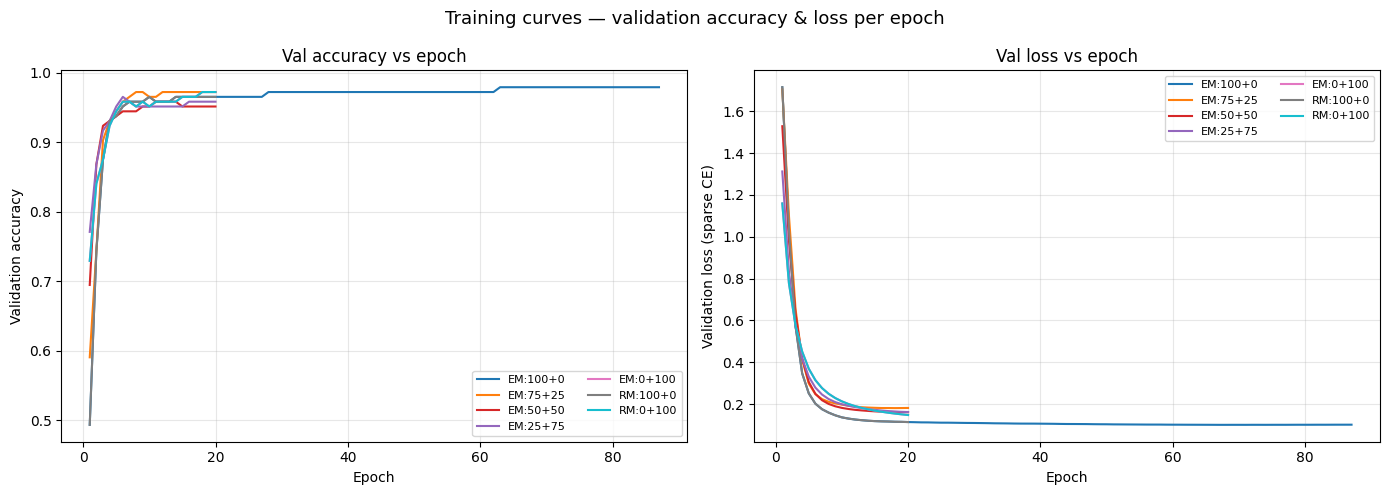

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training curves — validation accuracy & loss per epoch", fontsize=13)

for tag in MODEL_SPECS:
    val_acc  = get_curve(tag, "val_accuracy")
    val_loss = get_curve(tag, "val_loss")
    epochs   = np.arange(1, len(val_acc) + 1)
    color    = PALETTE[tag]

    axes[0].plot(epochs, val_acc,  color=color, label=tag, linewidth=1.5)
    axes[1].plot(epochs, val_loss, color=color, label=tag, linewidth=1.5)

for ax, ylabel, title in zip(
    axes,
    ["Validation accuracy", "Validation loss (sparse CE)"],
    ["Val accuracy vs epoch", "Val loss vs epoch"],
):
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3. Final performance comparison

Bar charts display the three summary metrics side by side, sorted by descending test
accuracy. The dashed horizontal line marks the best reference model (`RM:*`) result,
making it easy to see which — if any — `MultiDense` configurations outperform the
homogeneous baselines.


C:\Users\pablo\AppData\Local\Temp\ipykernel_10224\562325989.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tags_sorted, rotation=30, ha="right", fontsize=9)
C:\Users\pablo\AppData\Local\Temp\ipykernel_10224\562325989.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tags_sorted, rotation=30, ha="right", fontsize=9)
C:\Users\pablo\AppData\Local\Temp\ipykernel_10224\562325989.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tags_sorted, rotation=30, ha="right", fontsize=9)


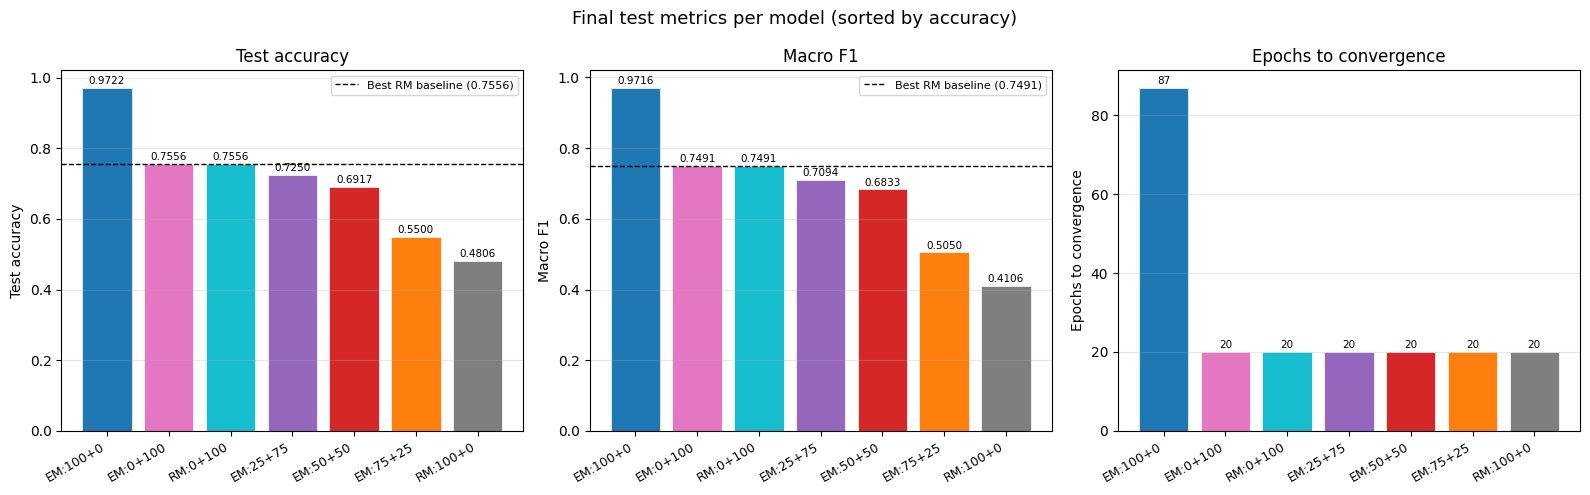

In [12]:
tags_sorted = sorted(results, key=lambda t: results[t]["test_accuracy"], reverse=True)

best_rm_acc = max(results[t]["test_accuracy"] for t in results if t.startswith("RM"))
best_rm_f1  = max(results[t]["macro_f1"]      for t in results if t.startswith("RM"))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Final test metrics per model (sorted by accuracy)", fontsize=13)

metric_info = [
    ("test_accuracy", "Test accuracy",            best_rm_acc),
    ("macro_f1",      "Macro F1",                 best_rm_f1),
    ("n_epochs",      "Epochs to convergence",    None),
]

for ax, (key, label, best_rm) in zip(axes, metric_info):
    values = [results[t][key] for t in tags_sorted]
    colors = [PALETTE[t] for t in tags_sorted]
    bars   = ax.bar(tags_sorted, values, color=colors, edgecolor="white", linewidth=0.5)

    if best_rm is not None:
        ax.axhline(best_rm, color="black", linestyle="--", linewidth=1,
                   label=f"Best RM baseline ({best_rm:.4f})")
        ax.legend(fontsize=8)

    ax.set_title(label)
    ax.set_ylabel(label)
    ax.set_xticklabels(tags_sorted, rotation=30, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, values):
        fmt = f"{val:.4f}" if isinstance(val, float) else str(val)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ax.get_ylim()[1] * 0.005,
            fmt, ha="center", va="bottom", fontsize=7.5
        )

plt.tight_layout()
plt.show()

### 7.4. Confusion matrices

A confusion matrix for each model reveals *where* errors occur — which digits are
systematically confused with each other. Models with similar overall accuracy can differ
substantially in their error patterns, which is relevant for understanding whether
the activation mix changes the model's inductive bias.


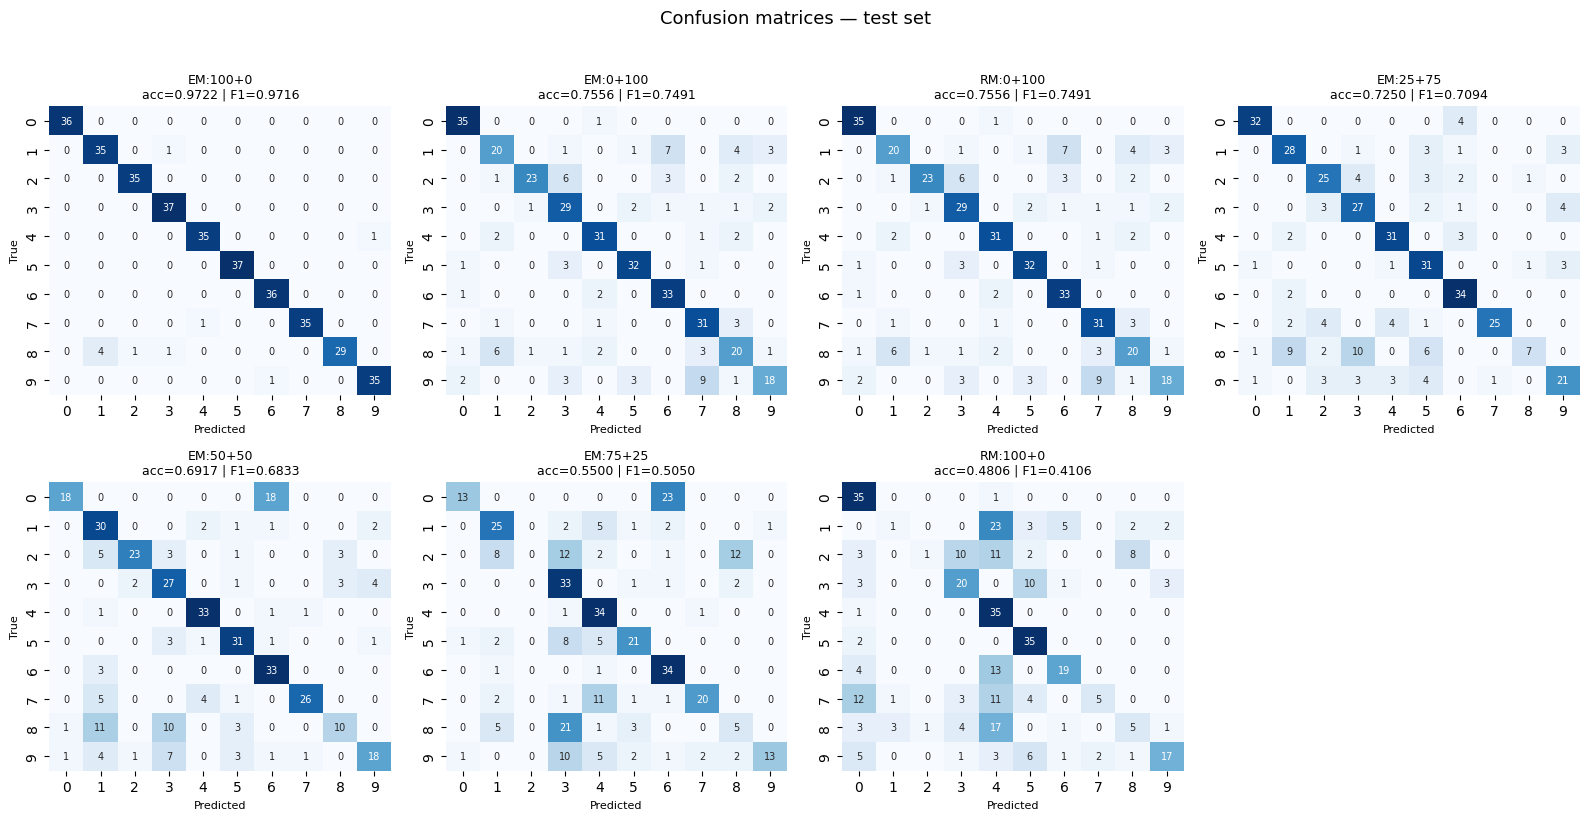

In [13]:
n_models = len(MODEL_SPECS)
n_cols   = 4
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes_flat = axes.flatten()

for ax, tag in zip(axes_flat, tags_sorted):
    cm    = results[tag]["conf_mat"]
    acc   = results[tag]["test_accuracy"]
    f1    = results[tag]["macro_f1"]

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=range(n_classes),
        yticklabels=range(n_classes),
        cbar=False, ax=ax, annot_kws={"size": 7},
    )
    ax.set_title(f"{tag}\nacc={acc:.4f} | F1={f1:.4f}", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True",      fontsize=8)

# Hide unused subplots
for ax in axes_flat[n_models:]:
    ax.set_visible(False)

fig.suptitle("Confusion matrices — test set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

----

## 8. Conclusions

The table below summarises all metrics, sorted by test accuracy. The `vs best RM` column
compares each model against the stronger of the two homogeneous `Dense` baselines,
flagging whether the mixed-activation approach brought a measurable benefit.


In [14]:
best_rm_acc = max(results[t]["test_accuracy"] for t in results if t.startswith("RM"))
best_rm_f1  = max(results[t]["macro_f1"]      for t in results if t.startswith("RM"))

header = f"{'Model':<14} {'Accuracy':>10} {'Macro F1':>10} {'Epochs':>8} {'vs best RM':>14}"
print(header)
print("-" * len(header))

for tag in tags_sorted:
    r     = results[tag]
    delta = r["test_accuracy"] - best_rm_acc
    if   delta >  1e-4: marker = "▲ better"
    elif delta < -1e-4: marker = "▼ worse"
    else:               marker = "≈ same"

    print(
        f"{tag:<14} {r['test_accuracy']:>10.4f} {r['macro_f1']:>10.4f}"
        f" {r['n_epochs']:>8d} {marker:>14}"
    )

Model            Accuracy   Macro F1   Epochs     vs best RM
------------------------------------------------------------
EM:100+0           0.9722     0.9716       87       ▲ better
EM:0+100           0.7556     0.7491       20         ≈ same
RM:0+100           0.7556     0.7491       20         ≈ same
EM:25+75           0.7250     0.7094       20        ▼ worse
EM:50+50           0.6917     0.6833       20        ▼ worse
EM:75+25           0.5500     0.5050       20        ▼ worse
RM:100+0           0.4806     0.4106       20        ▼ worse


----